In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.collections import LineCollection
from src.results_paper import *
from src.TimeSeriesAnalysis import *
from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output
from matplotlib.lines import Line2D

In [2]:
results_folder = "../results/Navigation/3D"
create_folder(results_folder)

In [ ]:
process_all_roots("../Data/bond_percolation", verbose=True, clean_outputs=False)
summarize_all_dirs("../Data/bond_percolation", verbose=True)
clear_output()

In [3]:
df = pd.read_csv("../Data/bond_percolation/all_data_3D.dat", sep=' ').sort_values('rho')
df

,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
6293,128,3000,0.000001,2,0.008523,1.0,0.5,2,700,0.692514,0.000886,134.052857,0.051446,7.032390e+05,1616.481873
6292,128,3000,0.000001,2,0.008523,1.0,0.5,1,700,0.697425,0.000877,134.040000,0.051641,7.009120e+05,1716.171344
3578,512,3000,0.000001,8,0.009970,1.0,0.1,7,50,0.257348,0.000077,1780.700000,3.611574,6.031849e+06,10270.214830
3577,512,3000,0.000001,8,0.009970,1.0,0.1,6,50,0.257250,0.000075,1781.540000,3.889831,6.030882e+06,10312.063840
3576,512,3000,0.000001,8,0.009970,1.0,0.1,5,50,0.256702,0.000081,1778.040000,3.623839,6.030314e+06,10282.289067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6922,512,3000,0.000001,2,0.500000,1.0,0.1,1,50,0.250217,0.000060,2979.000000,24.619372,9.876859e+06,65973.800474
6923,512,3000,0.000001,2,0.500000,1.0,0.1,2,50,0.250255,0.000057,3072.520000,21.069743,9.885095e+06,64681.009093
6360,128,3000,0.000001,2,0.500000,1.0,0.1,1,501,0.556967,0.000928,144.389222,0.165329,8.973682e+05,2663.674854
6362,128,3000,0.000001,2,0.500000,1.0,1.0,1,1,0.495806,0.010437,145.000000,0.000000,9.585250e+05,0.000000


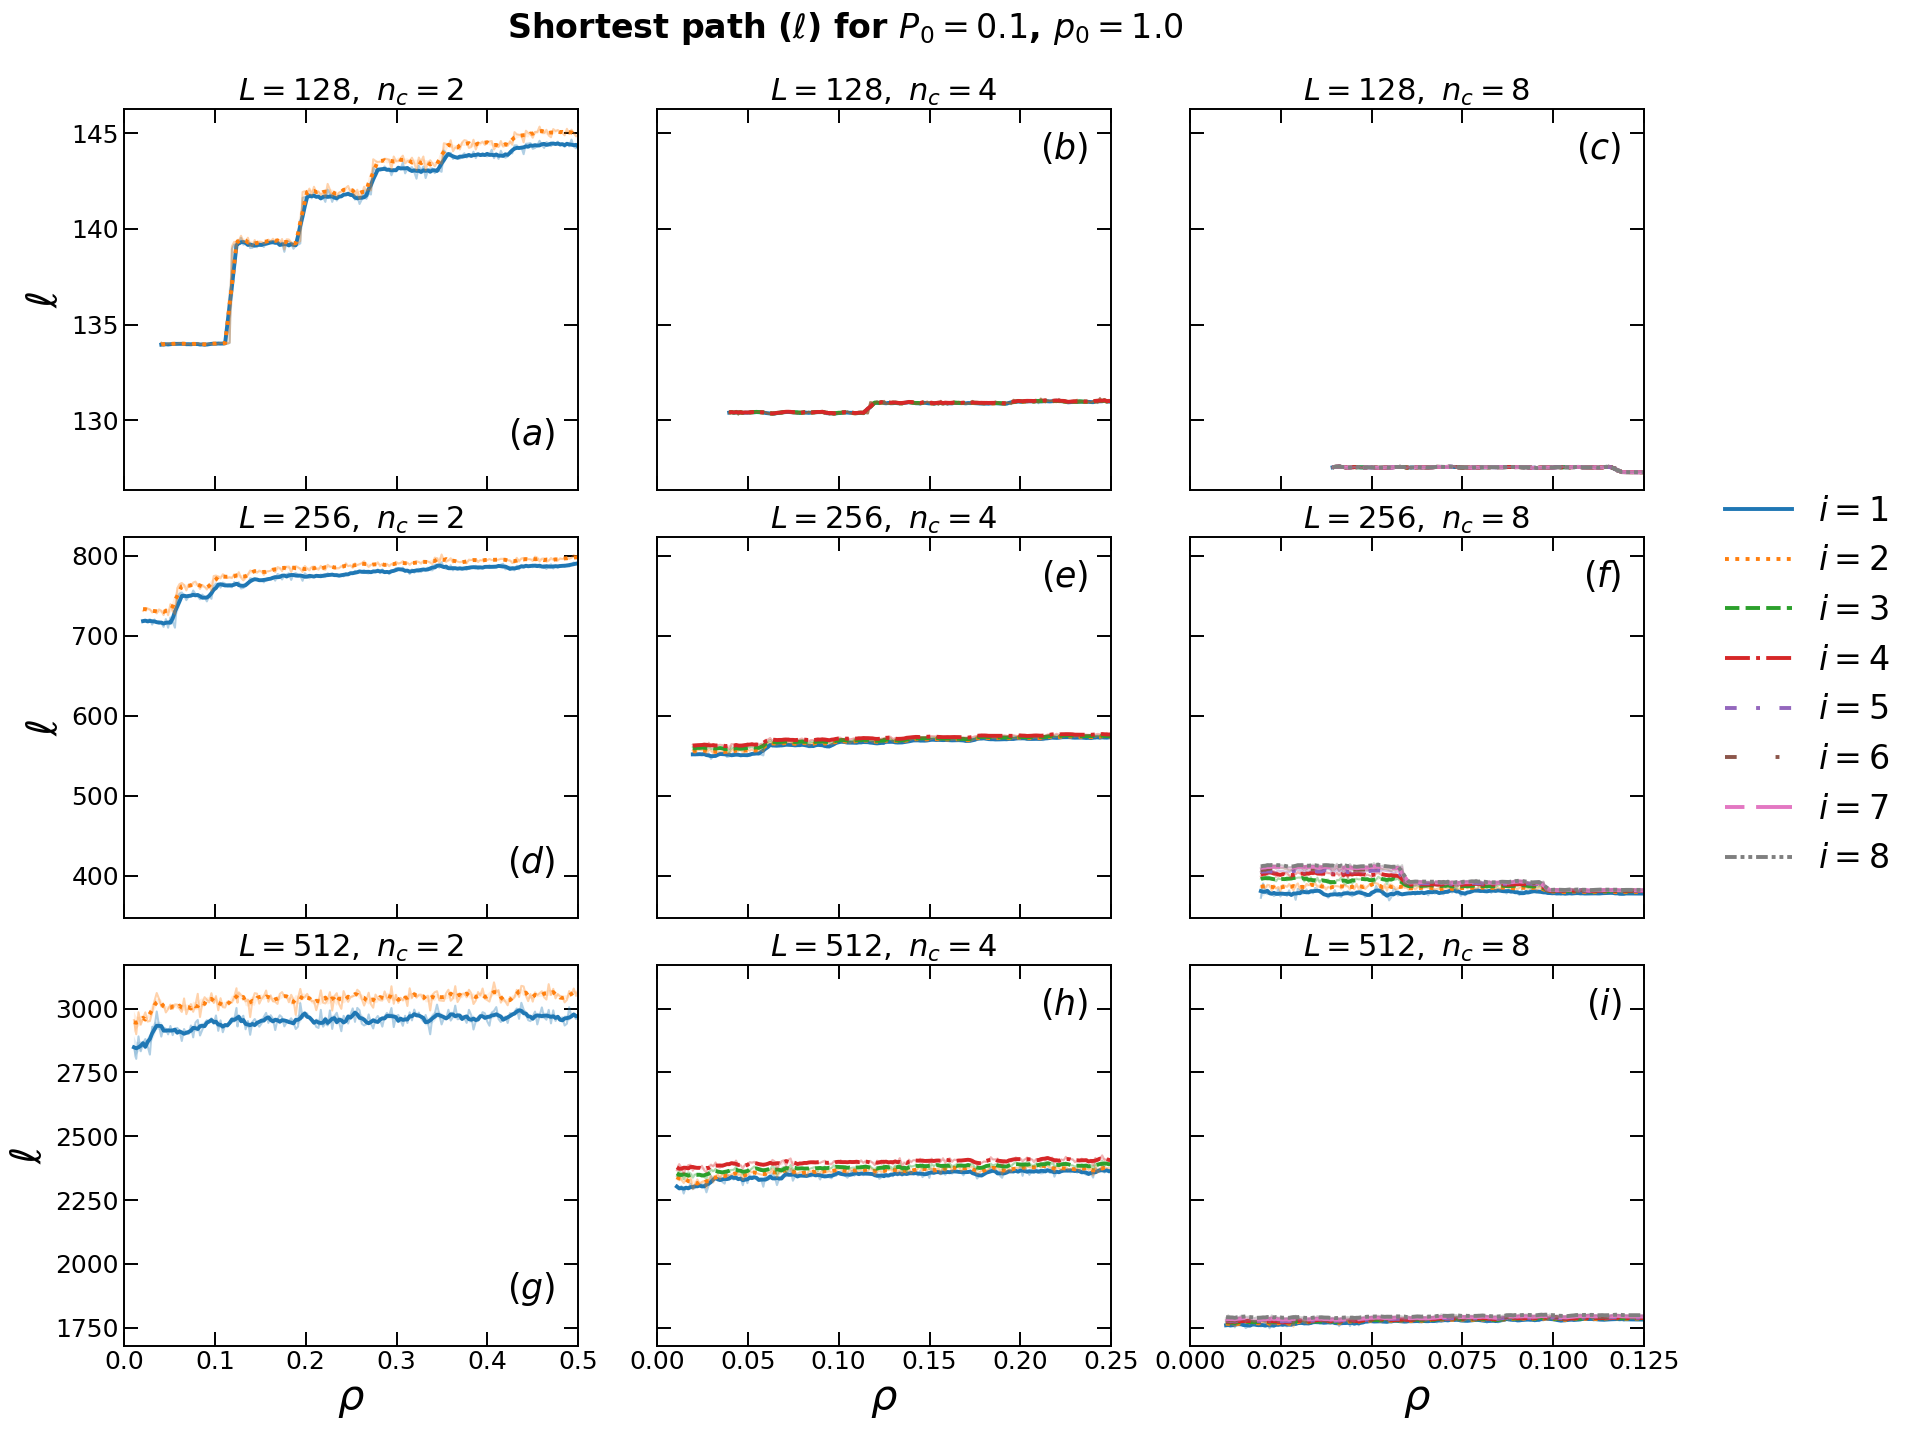

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L_list   = [128, 256, 512]     # linhas
NC_LIST  = [2, 4, 8]           # colunas
WINDOW   = 5
P0       = 0.1
p0       = 1.0

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

ls = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

labels_fig = ["$(a)$", "$(b)$", "$(c)$", 
              "$(d)$", "$(e)$", "$(f)$",
              "$(g)$", "$(h)$", "$(i)$"]

fig, axes = plt.subplots(3, 3, figsize=(17, 15), sharex='col', sharey='row')
thickness_axes = 1.4

legend_lines = {}

for i, L in enumerate(L_list):          # linhas -> L
    for j, nc in enumerate(NC_LIST):    # colunas -> n_c
        ax = axes[i, j]
        orders = list(range(1, nc + 1))
        count = 0

        for order in orders:
            df_f = df[
                (df["L"] == L) &
                (df["nc"] == nc) &
                (df["order"] == order) &
                (df["P0"] == P0) &
                (df["p0"] == p0)
            ].copy()

            if df_f.empty:
                continue

            df_f = df_f.sort_values("rho")

            x = df_f["rho"].to_numpy()
            y = df_f["shortest_path"].to_numpy()

            y_ma = (
                pd.Series(y)
                .rolling(window=WINDOW,
                         center=True,
                         min_periods=max(3, WINDOW // 2))
                .mean()
                .to_numpy()
            )
            y_std = (
                pd.Series(y)
                .rolling(window=WINDOW,
                         center=True,
                         min_periods=max(3, WINDOW // 2))
                .std()
                .to_numpy()
            )
            y_sem = y_std / np.sqrt(np.minimum(WINDOW, np.arange(1, len(y) + 1)))

            ax.plot(x, y, alpha=0.35)
            lines, = ax.plot(x, y_ma, linewidth=2*thickness_axes, color=colors[count],
                            ls=ls[count],
                            label=fr"$i = {order}$")
            ax.fill_between(x, y_ma - y_sem, y_ma + y_sem, alpha=0.12)
            count += 1
            if order not in legend_lines:
                legend_lines[order] = lines
        
        ax.set_xlim([0, 1 / nc])
        ax.tick_params(axis='both', which='major', direction='in',
                       length=10, width=thickness_axes, labelsize=18, top=True, bottom=True, right=True)
        for spine in ax.spines.values():
            spine.set_linewidth(thickness_axes)
        if(j==0):
            posx,posy = 0.95, 0.10
        else:
            posx,posy = 0.95, 0.85
        
        ax.text(posx, posy, labels_fig[i * len(NC_LIST) + j],
                transform=ax.transAxes, ha='right', va='bottom', fontsize=25)
#        ax.legend(fontsize=15)
        ax.set_title(rf"$L = {L},\ n_c = {nc}$", fontsize=22)

# rótulos só onde precisa
for i in range(3):
    axes[i, 0].set_ylabel(r"$\ell$", fontsize=30)
for j in range(3):
    axes[2, j].set_xlabel(r"$\rho$", fontsize=30)

# ordena por i e cria listas
handles = [legend_lines[i] for i in sorted(legend_lines.keys())]
labels = [fr'$i={i}$' for i in sorted(legend_lines.keys())]

# adiciona o handle do p_c
pc_handle = Line2D([0], [0], linestyle='--', linewidth=1.6, color='k')
handles.append(pc_handle)


fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
           frameon=False, fontsize=24)

fig.suptitle(fr"Shortest path ($\ell$) for $P_0 = {P0}$, $p_0 = {p0}$",
             fontsize=24, fontweight='bold',y=0.95)
fig.tight_layout(rect=[0, 0, 1, 0.95])  # deixa espaço para o suptitle
fig.savefig(
    results_folder + "/shortest_rho_L_nc.pdf",
    bbox_inches='tight',   # <- inclui a legenda na caixa
    pad_inches=0.05        # opcional, um espacinho extra
)
plt.show()


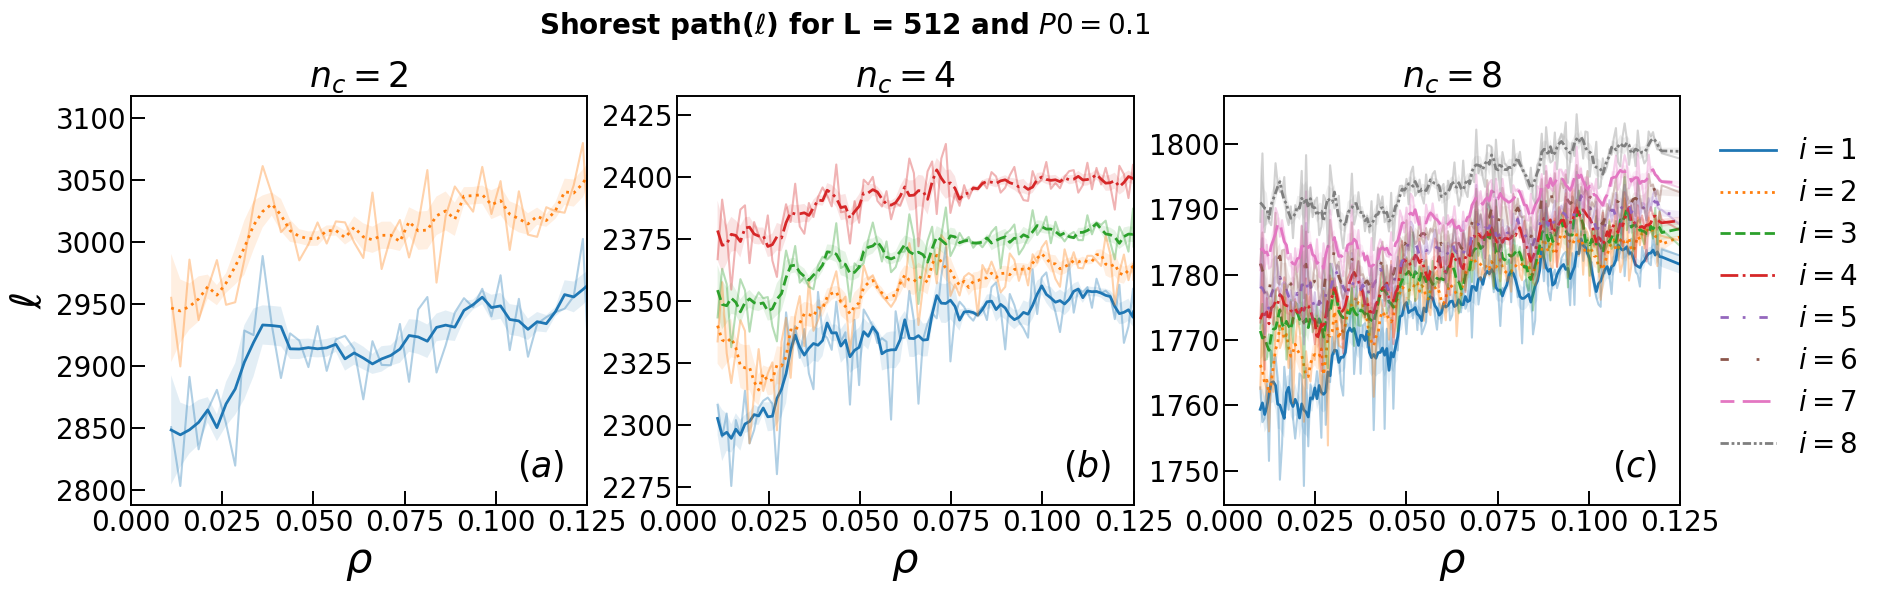

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L = 512
NC_LIST = [2, 4, 8]
WINDOW = 5
P0 = 0.1
p0 = 1.0

legend_lines = {}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharex=True)   # <<-- sem sharey
thickness_axes = 1.4

labels_fig = ["$(a)$", "$(b)$", "$(c)$", 
              "$(d)$", "$(e)$", "$(f)$",
              "$(g)$", "$(h)$", "$(i)$"]

index = 0 
for ax, nc in zip(axes, NC_LIST):
    orders = [i for i in range(1, nc+1)]
    count = 0
    for order in orders:
        df_f = df[(df["L"] == L) & (df["nc"] == nc) & (df["order"] == order) & (df["P0"]==P0) & (df["p0"]==p0)].copy()
        if df_f.empty:
            continue
        df_f = df_f.sort_values("rho")

        x = df_f["rho"].to_numpy()
        y = df_f["shortest_path"].to_numpy()

        y_ma = (
            pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2)).mean().to_numpy()
        )
        y_std = (
            pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2)).std().to_numpy()
        )
        y_sem = y_std / np.sqrt(np.minimum(WINDOW, np.arange(1, len(y)+1)))

        ax.plot(x, y, alpha=0.35)
        lines, = ax.plot(x, y_ma, linewidth=2,color=colors[count],
                         label=f"$i = {order}$", ls=ls[count])
        
        if order not in legend_lines:
            legend_lines[order] = lines
        
        ax.fill_between(x, y_ma - y_sem, y_ma + y_sem, alpha=0.12)
        count += 1
    # limites e ticks específicos por painel
    #ax.set_ylim(ylim)
    #yticks = np.linspace(ylim[0], ylim[1], 6)           # ajuste o número de ticks se quiser
    #ax.set_yticks(yticks)
    #ax.set_yticklabels([f"${t:.3f}$" for t in yticks])
    
    ax.set_title(rf"$n_c = {nc}$",fontsize=25)
    ax.set_xlabel(r"$\rho$",fontsize=30)
    ax.set_xlim([0, 1/nc])
    
    ax.tick_params(axis='both', which='major', direction='in', length=10, width=thickness_axes, labelsize=20)
    for spine in ax.spines.values():
        spine.set_linewidth(thickness_axes)
    
    ax.text(0.95, 0.05, labels_fig[index],
                transform=ax.transAxes, ha='right', va='bottom', fontsize=25)
    index += 1
handles = [legend_lines[i] for i in sorted(legend_lines.keys())]

labels = [fr'$i={i}$' for i in sorted(legend_lines.keys())]

# adiciona o handle do p_c
pc_handle = Line2D([0], [0], linestyle='--', linewidth=1.6, color='k')
handles.append(pc_handle)


fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
           frameon=False, fontsize=20)

axes[0].set_ylabel(r"$\ell$",fontsize=30)

fig.suptitle(fr"Shorest path($\ell$) for L = {L} and $P0 = {P0}$", fontsize=20, fontweight='bold') # Adds a title to the entire figure
fig.tight_layout()
fig.savefig(
    results_folder + f"/shortest_L_{L}.pdf",
    bbox_inches='tight',   # <- inclui a legenda na caixa
    pad_inches=0.05        # opcional, um espacinho extra
)
plt.show()


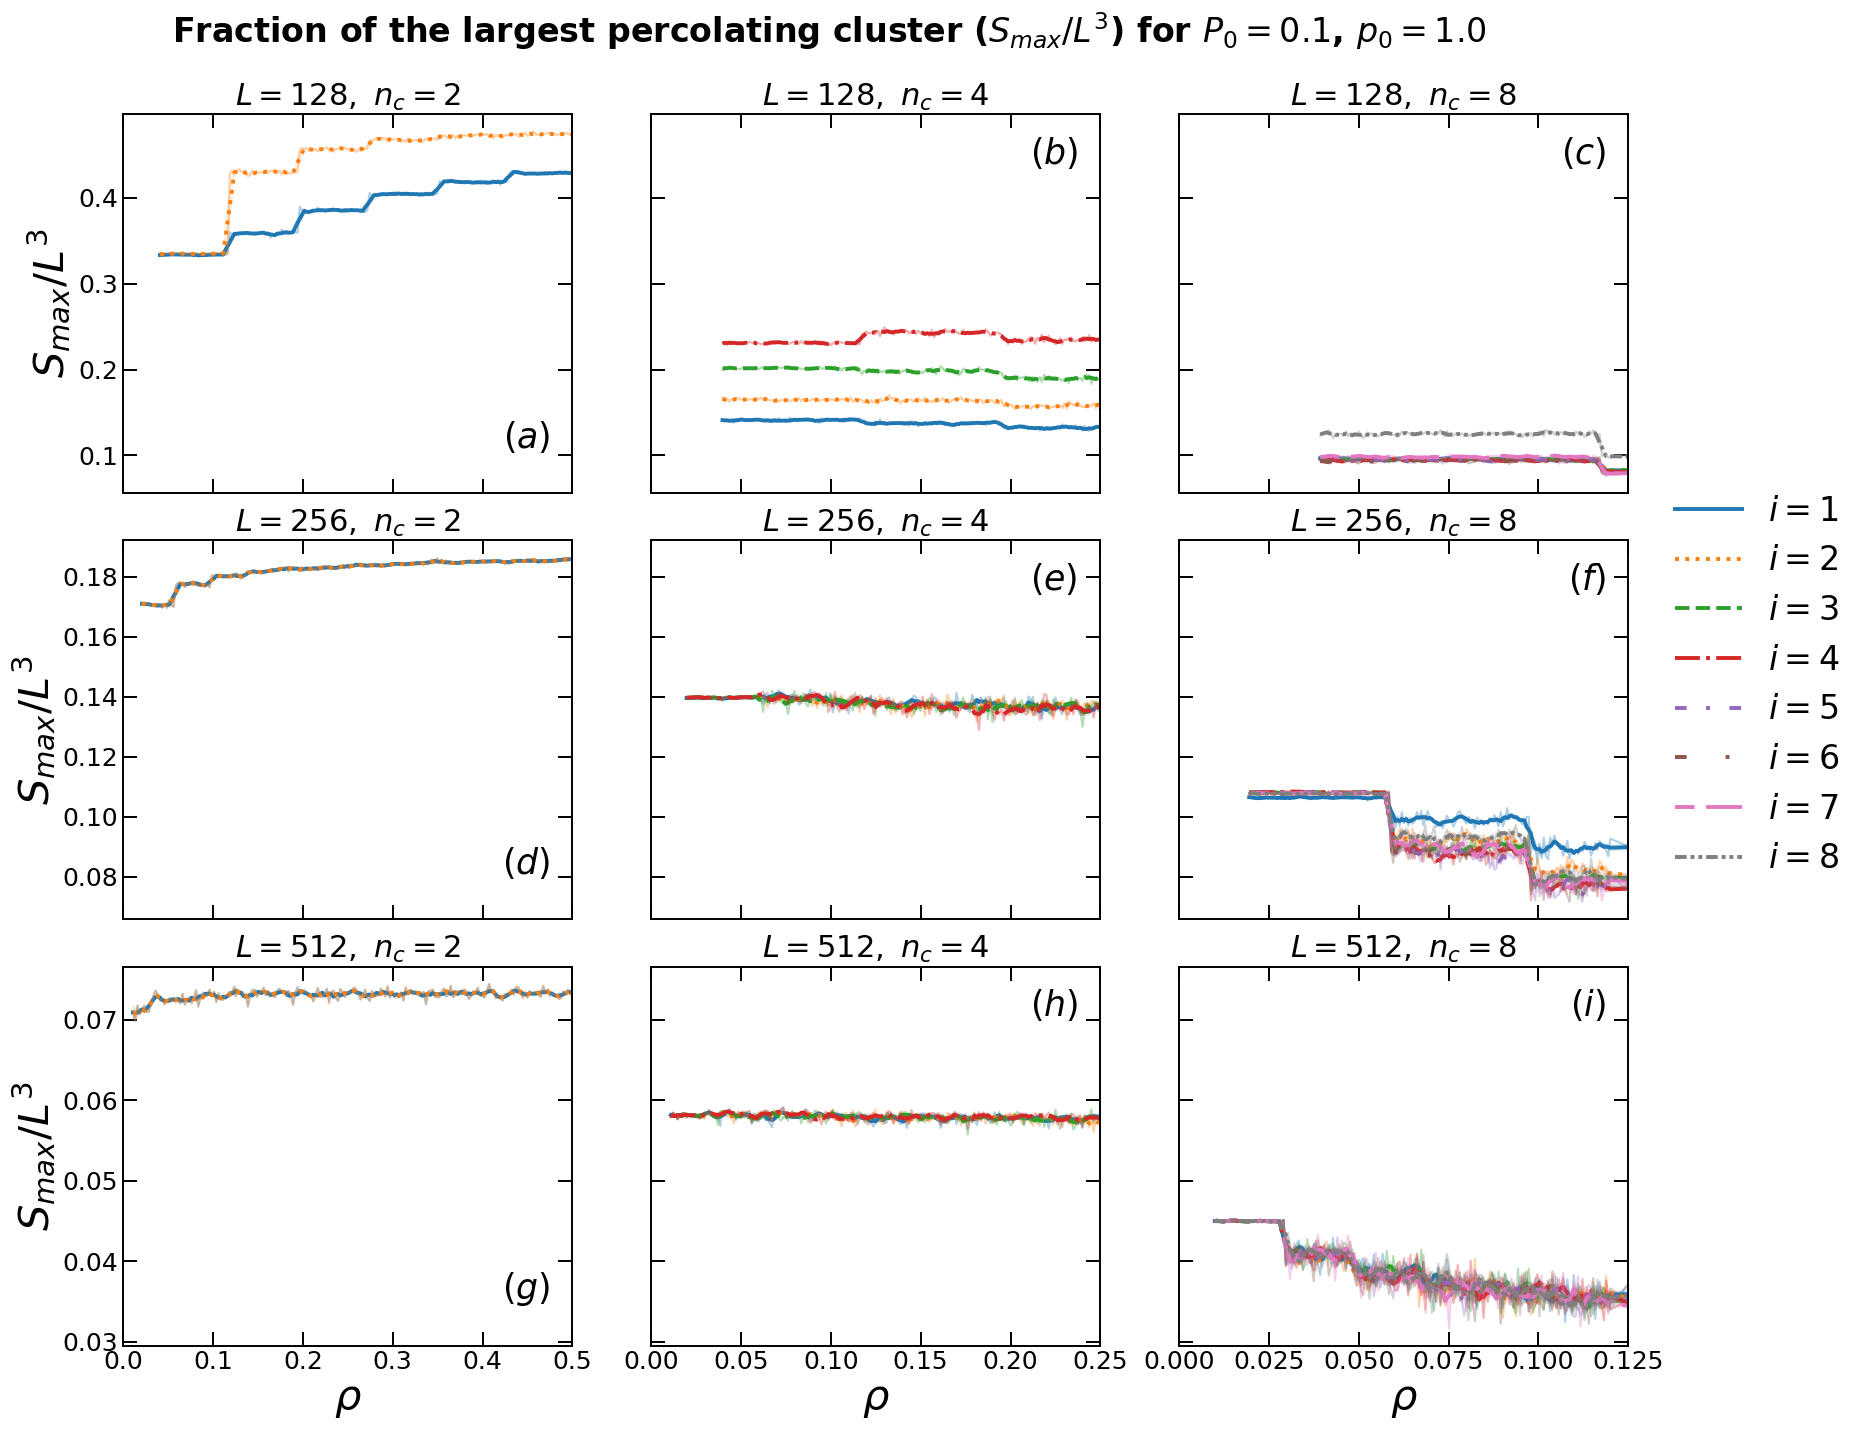

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L_list   = [128, 256, 512]     # linhas
NC_LIST  = [2, 4, 8]           # colunas
WINDOW   = 5
P0       = 0.1
p0       = 1.0

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

ls = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

labels_fig = ["$(a)$", "$(b)$", "$(c)$", 
              "$(d)$", "$(e)$", "$(f)$",
              "$(g)$", "$(h)$", "$(i)$"]

fig, axes = plt.subplots(3, 3, figsize=(17, 15), sharex='col', sharey='row')
thickness_axes = 1.4

legend_lines = {}

for i, L in enumerate(L_list):          # linhas -> L
    for j, nc in enumerate(NC_LIST):    # colunas -> n_c
        ax = axes[i, j]
        orders = list(range(1, nc + 1))
        count = 0

        for order in orders:
            df_f = df[
                (df["L"] == L) &
                (df["nc"] == nc) &
                (df["order"] == order) &
                (df["P0"] == P0) &
                (df["p0"] == p0)
            ].copy()

            if df_f.empty:
                continue

            df_f = df_f.sort_values("rho")
            VOL = L**3
            x = df_f["rho"].to_numpy()
            y = df_f["S_perc"].to_numpy()/VOL

            y_ma = (
                pd.Series(y)
                .rolling(window=WINDOW,
                         center=True,
                         min_periods=max(3, WINDOW // 2))
                .mean()
                .to_numpy()
            )
            y_std = (
                pd.Series(y)
                .rolling(window=WINDOW,
                         center=True,
                         min_periods=max(3, WINDOW // 2))
                .std()
                .to_numpy()
            )
            y_sem = y_std / np.sqrt(np.minimum(WINDOW, np.arange(1, len(y) + 1)))

            ax.plot(x, y, alpha=0.35)
            lines, = ax.plot(x, y_ma, linewidth=2*thickness_axes, color=colors[count],
                            ls=ls[count],
                            label=fr"$i = {order}$")
            ax.fill_between(x, y_ma - y_sem, y_ma + y_sem, alpha=0.12)
            count += 1
            if order not in legend_lines:
                legend_lines[order] = lines
        
        ax.set_xlim([0, 1 / nc])
        ax.tick_params(axis='both', which='major', direction='in',
                       length=10, width=thickness_axes, labelsize=18, top=True, bottom=True, right=True)
        for spine in ax.spines.values():
            spine.set_linewidth(thickness_axes)
        if(j==0):
            posx,posy = 0.95, 0.10
        else:
            posx,posy = 0.95, 0.85
        
        ax.text(posx, posy, labels_fig[i * len(NC_LIST) + j],
                transform=ax.transAxes, ha='right', va='bottom', fontsize=25)
#        ax.legend(fontsize=15)
        ax.set_title(rf"$L = {L},\ n_c = {nc}$", fontsize=22)

# rótulos só onde precisa
for i in range(3):
    axes[i, 0].set_ylabel(r"$S_{max}/L^3$", fontsize=30)
for j in range(3):
    axes[2, j].set_xlabel(r"$\rho$", fontsize=30)

# ordena por i e cria listas
handles = [legend_lines[i] for i in sorted(legend_lines.keys())]
labels = [fr'$i={i}$' for i in sorted(legend_lines.keys())]

# adiciona o handle do p_c
pc_handle = Line2D([0], [0], linestyle='--', linewidth=1.6, color='k')
handles.append(pc_handle)

fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.98, 0.5),
           frameon=False, fontsize=24)

fig.suptitle(fr"Fraction of the largest percolating cluster ($S_{{max}}/L^3$) for $P_0 = {P0}$, $p_0 = {p0}$",
             fontsize=24, fontweight='bold',y=0.95)
fig.tight_layout(rect=[0, 0, 1, 0.95])  # deixa espaço para o suptitle
fig.savefig(
    results_folder + "/Smax_rho_L_nc.pdf",
    bbox_inches='tight',   # <- inclui a legenda na caixa
    pad_inches=0.05        # opcional, um espacinho extra
)
plt.show()


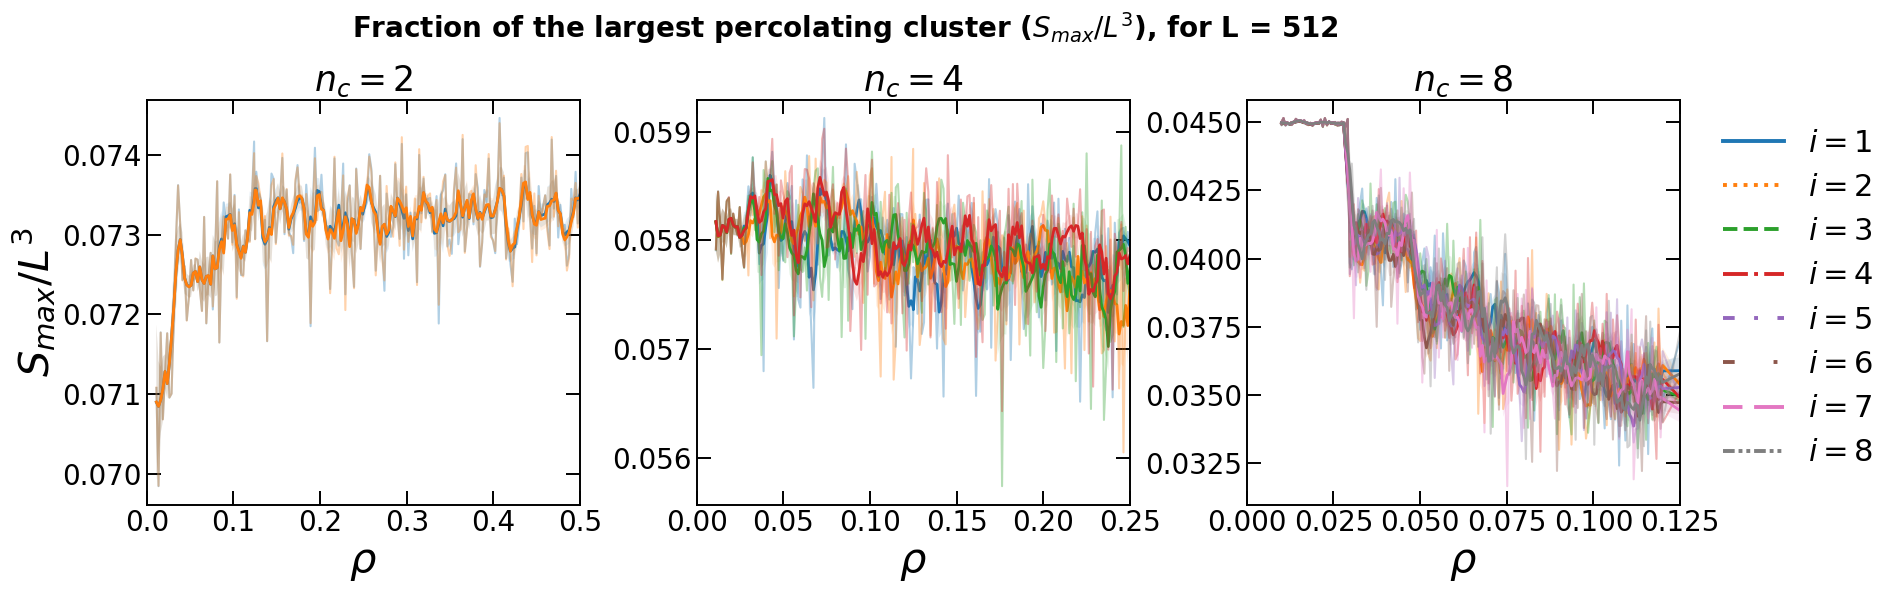

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L = 512
VOL = L**3
NC_LIST = [2, 4, 8]
WINDOW = 5
P0 = 0.1
p0 = 1.0
#ylims = [(0.2550, 0.2575), (0.262, 0.272), (0.26, 0.36)]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=False)   # <<-- sem sharey
thickness_axes = 1.4

legend_lines = {}

for ax, nc in zip(axes, NC_LIST):
    orders = [i for i in range(1, nc+1)]
    count = 0
    for order in orders:
        df_f = df[(df["L"] == L) & (df["nc"] == nc) & (df["order"] == order) & (df["P0"]==P0) & (df["p0"]==p0)].copy()
        if df_f.empty:
            continue
        df_f = df_f.sort_values("rho")

        x = df_f["rho"].to_numpy()
        y = df_f["S_perc"].to_numpy()/VOL

        y_ma = (
            pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2)).mean().to_numpy()
        )
        y_std = (
            pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2)).std().to_numpy()
        )
        y_sem = y_std / np.sqrt(np.minimum(WINDOW, np.arange(1, len(y)+1)))

        ax.plot(x, y, alpha=0.35)
        lines, = ax.plot(x, y_ma, linewidth=2,color=colors[count] ,label=f"$i = {order}$")
        ax.fill_between(x, y_ma - y_sem, y_ma + y_sem, alpha=0.12)
        count += 1
        
        if order not in legend_lines:
            legend_lines[order] = lines
    # limites e ticks específicos por painel
    #ax.set_ylim(ylim)
    #yticks = np.linspace(ylim[0], ylim[1], 6)           # ajuste o número de ticks se quiser
    #ax.set_yticks(yticks)
    #ax.set_yticklabels([f"${t:.3f}$" for t in yticks])
    
    ax.set_title(rf"$n_c = {nc}$",fontsize=25)
    ax.set_xlabel(r"$\rho$",fontsize=30)
    ax.set_xlim([0, 1/nc])
    ax.tick_params(axis='both', which='major', direction='in', length=10, width=thickness_axes, labelsize=20, top=True, right=True)
    for spine in ax.spines.values():
        spine.set_linewidth(thickness_axes)
    
axes[0].set_ylabel(r"$S_{max}/L^3$",fontsize=30)
fig.suptitle(fr"Fraction of the largest percolating cluster ($S_{{max}}/L^3$), for L = {L}", fontsize=20, fontweight='bold') # Adds a title to the entire figure

pc_handle = Line2D([0], [0], linestyle='--', linewidth=1.6, color='k')
handles.append(pc_handle)

fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
           frameon=False, fontsize=22)

fig.tight_layout()
fig.savefig(
    results_folder + f"/Smax_rho_L_{L}.pdf",
    bbox_inches='tight',   # <- inclui a legenda na caixa
    pad_inches=0.05        # opcional, um espacinho extra
)
plt.show()


In [ ]:
L_lst = [128, 256, 512]
nc = 8
rho = 0.12
orders = [i for i in range(1,nc+1)]
for L in L_lst:
    df_filter = df[(df["nc"]==nc) & (df["rho"]==rho) & (df["L"]==L)]
    
    print(df_filter)

        L    Nt         k  nc   rho   p0   P0  order  N_samples    p_mean  \
2912  128  3000  0.000001   8  0.12  1.0  0.1      1        500  0.999739   
2913  128  3000  0.000001   8  0.12  1.0  0.1      2        500  0.999052   
2915  128  3000  0.000001   8  0.12  1.0  0.1      4        500  0.998979   
2914  128  3000  0.000001   8  0.12  1.0  0.1      3        500  0.995658   
2919  128  3000  0.000001   8  0.12  1.0  0.1      8        500  0.996800   
2918  128  3000  0.000001   8  0.12  1.0  0.1      7        500  0.996460   
2917  128  3000  0.000001   8  0.12  1.0  0.1      6        500  0.999755   
2916  128  3000  0.000001   8  0.12  1.0  0.1      5        500  0.996120   

         p_err  shortest_path  shortest_path_err      S_perc   S_perc_err  
2912  0.000008        127.258           0.024982  172762.266  3098.967678  
2913  0.000022        127.258           0.024982  172132.302  2934.505002  
2915  0.000028        127.256           0.024620  167274.284  2942.689440  
29